In [4]:
from geotessera import GeoTessera

# Initialize the client
gt = GeoTessera()

# Method 1: Fetch a single tile
embedding, crs, transform = gt.fetch_embedding(lon=0.15, lat=52.05, year=2024)
print(f"Shape: {embedding.shape}")  # e.g., (1200, 1200, 128)
print(f"CRS: {crs}")  # Coordinate reference system from landmask

# # Method 2: Fetch all tiles in a bounding box
# bbox = (-0.2, 51.4, 0.1, 51.6)  # (min_lon, min_lat, max_lon, max_lat)
# tiles_to_fetch = gt.registry.load_blocks_for_region(bounds=bbox, year=2024)
# embeddings = gt.fetch_embeddings(tiles_to_fetch)

# for year, tile_lon, tile_lat, embedding_array, crs, transform in embeddings:
#     print(f"Tile ({tile_lat}, {tile_lon}): {embedding_array.shape}")

Shape: (1139, 729, 128)
CRS: EPSG:32631


In [50]:
# Download embedding for Cambridge (note: lon, lat order)
lon, lat = -7.380043, 40.303520
year = 2021

embedding, crs, transform = gt.fetch_embedding(lon=lon, lat=lat, year=year)

print(f"Embedding shape: {embedding.shape}")
print(f"Data type: {embedding.dtype}")
print(f"CRS: {crs}")
print(f"Transform: {transform}")
print(f"Value range: [{embedding.min():.3f}, {embedding.max():.3f}]")
print(f"Memory usage: {embedding.nbytes / 1024**2:.1f} MB")


Embedding shape: (1126, 870, 128)
Data type: float32
CRS: EPSG:32629
Transform: | 10.00, 0.00, 635778.13|
| 0.00,-10.00, 4473542.18|
| 0.00, 0.00, 1.00|
Value range: [-13.944, 13.004]
Memory usage: 478.3 MB


In [56]:
# Download embedding for Cambridge (note: lon, lat order)
lon, lat =  -8.35, 40.35
year = 2021

embedding1, crs1, transform1 = gt.fetch_embedding(lon=lon, lat=lat, year=year)

print(f"Embedding shape: {embedding1.shape}")
print(f"Data type: {embedding1.dtype}")
print(f"CRS: {crs1}")
print(f"Transform: {transform1}")
print(f"Value range: [{embedding1.min():.3f}, {embedding1.max():.3f}]")
print(f"Memory usage: {embedding1.nbytes / 1024**2:.1f} MB")


Embedding shape: (1116, 857, 128)
Data type: float32
CRS: EPSG:32629
Transform: | 10.00, 0.00, 550915.88|
| 0.00,-10.00, 4472390.03|
| 0.00, 0.00, 1.00|
Value range: [-14.013, 12.617]
Memory usage: 467.0 MB


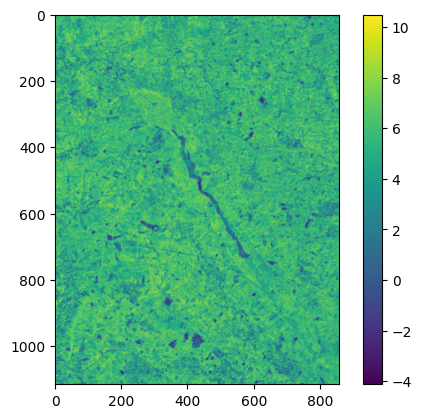

In [57]:
import matplotlib.pyplot as plt

plt.imshow(embedding1[:, :, 0])
plt.colorbar()
plt.show()

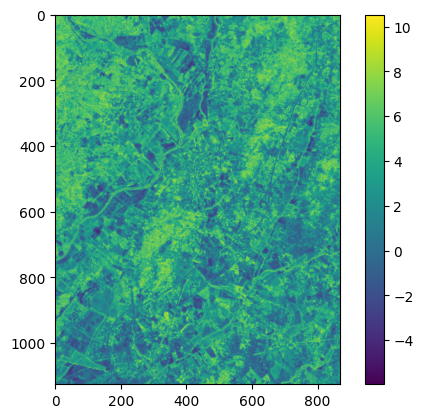

In [53]:
import matplotlib.pyplot as plt

plt.imshow(embedding[:, :, 0])
plt.colorbar()
plt.show()

In [73]:
from geotessera import GeoTessera
import numpy as np

gt = GeoTessera()

# Define points of interest (lon, lat tuples)
points = [
    (-7.380043, 40.303520),   # portugal 2021 arvores
    #(-8.501346, 40.577960),  
]

# Sample embeddings at these points (auto-downloads tiles if needed)
embeddings, metadata = gt.sample_embeddings_at_points(points, year=2021, include_metadata=True)
print(f"Sampled embeddings shape: {embeddings.shape}")  # (2, 128)

# Analyze the sampled embeddings
for i, point in enumerate(points):
    print(f"Point {i} ({point[0]}, {point[1]}):")
    print(f"  Mean: {np.mean(embeddings[i]):.3f}")
    print(f"  Std: {np.std(embeddings[i]):.3f}")
    print(f"  First 5 channels: {embeddings[i][:5]}")

print(metadata)

Sampled embeddings shape: (1, 128)
Point 0 (-7.380043, 40.30352):
  Mean: -0.099
  Std: 2.377
  First 5 channels: [ 3.7252944 -3.3662298  1.0323105  2.2441533 -2.6032178]
[{'tile_lon': -7.35, 'tile_lat': 40.35, 'pixel_row': np.int32(1083), 'pixel_col': np.int32(188), 'crs': 'EPSG:32629'}]


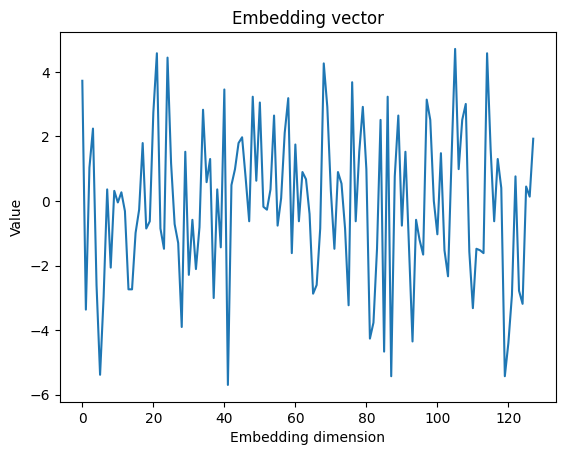

In [66]:
import matplotlib.pyplot as plt

plt.plot(embeddings.squeeze())
plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.title("Embedding vector")
plt.show()

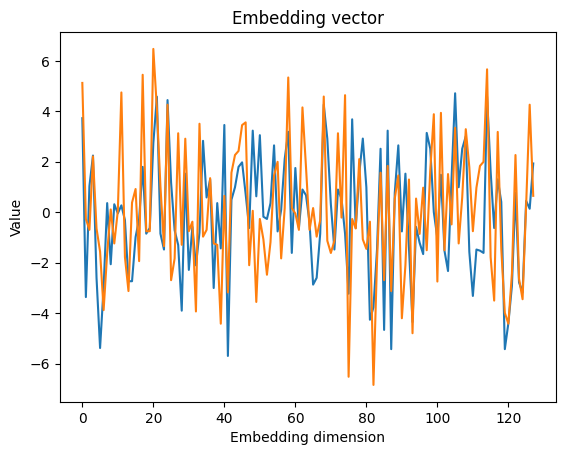

In [85]:
import matplotlib.pyplot as plt
plt.plot(embeddings.squeeze())
plt.plot(embeddings2.squeeze())
plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.title("Embedding vector")
plt.show()

In [87]:
from geotessera import GeoTessera
import numpy as np

gt = GeoTessera(embeddings_dir="_data/embeddings_dir")

# Define points of interest (lon, lat tuples)
points = [
    (-8.50, 40.57),   # portugal 2021 arvores
    #(-8.501346, 40.577960),  
]

# Sample embeddings at these points (auto-downloads tiles if needed)
embeddings2, metadata2 = gt.sample_embeddings_at_points(points, year=2021, include_metadata=True)
print(f"Sampled embeddings shape: {embeddings2.shape}")  # (2, 128)

# Analyze the sampled embeddings
for i, point in enumerate(points):
    print(f"Point {i} ({point[0]}, {point[1]}):")
    print(f"  Mean: {np.mean(embeddings2[i]):.3f}")
    print(f"  Std: {np.std(embeddings2[i]):.3f}")
    print(f"  First 5 channels: {embeddings2[i][:5]}")

print(metadata2)

Sampled embeddings shape: (1, 128)
Point 0 (-8.5, 40.57):
  Mean: 0.063
  Std: 2.629
  First 5 channels: [ 5.1231847  -0.2696413  -0.7010674   2.2110586  -0.64713913]
[{'tile_lon': -8.45, 'tile_lat': 40.55, 'pixel_row': np.int32(338), 'pixel_col': np.int32(1), 'crs': 'EPSG:32629'}]


Sampled embeddings shape: (1, 128)
Point 0 (-8.5, 40.58):
  Mean: -0.148
  Std: 2.498
  First 5 channels: [ 7.2460303  -1.3693286  -0.51349825  0.798775   -0.798775  ]
[{'tile_lon': -8.45, 'tile_lat': 40.55, 'pixel_row': np.int32(227), 'pixel_col': np.int32(1), 'crs': 'EPSG:32629'}]

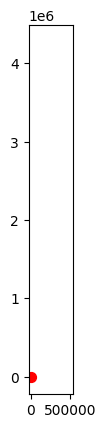

In [78]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

pixel_row = 53
pixel_col = 832

with rasterio.open("global_0.1_degree_tiff_all/grid_-8.55_40.55.tiff") as src:
    fig, ax = plt.subplots()
    show(src, ax=ax)

    # plot the point
    ax.scatter(pixel_col, pixel_row, color="red", s=50, marker="o")

plt.show()

In [ ]:
# Sample with metadata
embeddings, metadata = gt.sample_embeddings_at_points(
    points, year=2024, include_metadata=True
)

for i, meta in enumerate(metadata):
    print(f"Point {i}:")
    print(f"  From tile: ({meta['tile_lon']}, {meta['tile_lat']})")
    print(f"  Pixel location: row={meta['pixel_row']}, col={meta['pixel_col']}")
    print(f"  CRS: {meta['crs']}")

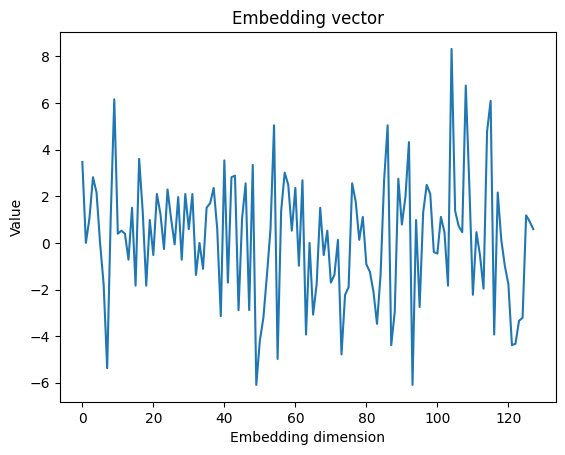

In [31]:
import matplotlib.pyplot as plt

point = embeddings.squeeze()   # shape becomes (128,)

plt.plot(point)
plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.title("Embedding vector")
plt.show()

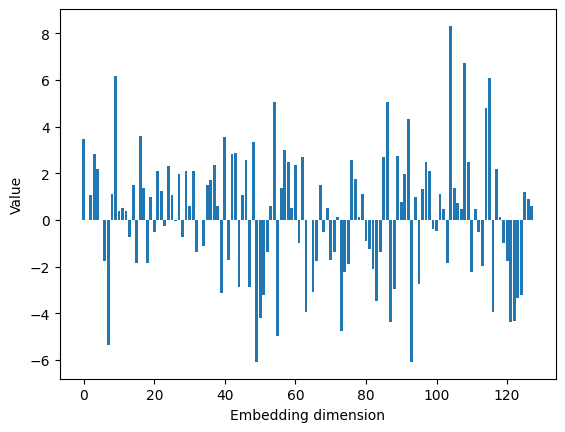

In [32]:
plt.bar(range(128), point)
plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.show()

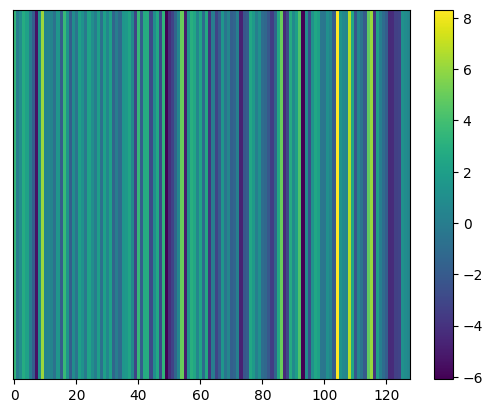

In [33]:
plt.imshow(point.reshape(1, -1), aspect="auto", cmap="viridis")
plt.yticks([])
plt.colorbar()
plt.show()

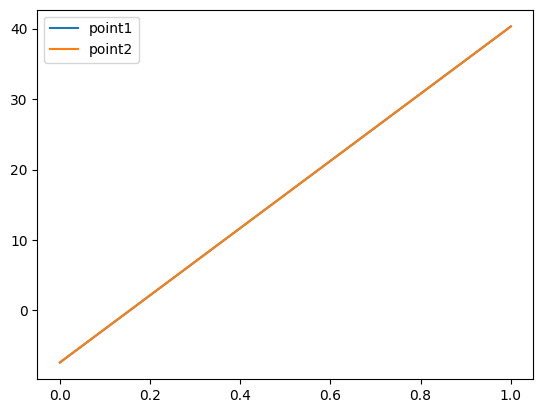

In [63]:
plt.plot(point, label="point1")
plt.plot(point, label="point2")
plt.legend()
plt.show()

In [9]:
# Export embeddings for a region as individual GeoTIFF files
# Step 1: Get the tiles for the region
bbox = (-0.2, 51.4, 0.1, 51.6)
tiles_to_fetch = gt.registry.load_blocks_for_region(bounds=bbox, year=2024)

# Step 2: Export those tiles as GeoTIFFs
files = gt.export_embedding_geotiffs(
    tiles_to_fetch=tiles_to_fetch,
    output_dir="./output",
    bands=None,  # Export all 128 bands (default)
    compress="lzw"  # Compression method
)

print(f"Created {len(files)} GeoTIFF files")

# Export specific bands only (e.g., first 3 for RGB visualization)
files = gt.export_embedding_geotiffs(
    tiles_to_fetch=tiles_to_fetch,
    output_dir="./rgb_output",
    bands=[0, 1, 2]  # Only export first 3 bands
)

Created 20 GeoTIFF files


In [80]:
pa="global_0.1_degree_tiff_all/grid_-8.55_40.55.tiff"

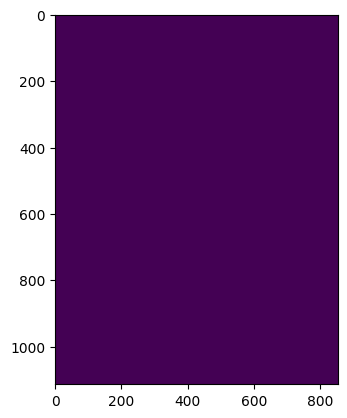

In [82]:
with rasterio.open(pa) as src:
    rgb = src.read()

rgb = rgb.transpose(1,2,0)

plt.imshow(rgb)
plt.show()

In [10]:
from geotessera.visualization import (
    create_rgb_mosaic,
    visualize_global_coverage
)
from geotessera.web import (
    create_coverage_summary_map,
    geotiff_to_web_tiles
)

# Create an RGB mosaic from multiple GeoTIFF files
create_rgb_mosaic(
    geotiff_paths=["tile1.tif", "tile2.tif"],
    output_path="mosaic.tif",
    bands=(0, 1, 2)  # RGB bands
)

# Generate web tiles for interactive maps
geotiff_to_web_tiles(
    geotiff_path="mosaic.tif",
    output_dir="./web_tiles",
    zoom_levels=(8, 15)
)

# Create a global coverage visualization
visualize_global_coverage(
    tessera_client=gt,
    output_path="global_coverage.png",
    year=2024,  # Or None for all years
    width_pixels=2000,
    tile_color="red",
    tile_alpha=0.6
)

RasterioIOError: tile1.tif: No such file or directory